$$ \huge{Data\ Clearning} $$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
%matplotlib inline

In [2]:
mydata=  pd.read_csv('marketing_campaign_data_messy (2).csv')
mydata.head()

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA


In [89]:
print(mydata.columns.tolist())
mydata.columns = mydata.columns.str.strip().str.lower().str.replace(' ', '_')
print('Fix Applied')
print(mydata.columns.tolist())



[' Campaign_ID ', 'Campaign_Name', 'Start_Date', 'End_Date', 'Channel', 'Impressions', 'Clicks ', 'Spend', 'Conversions', 'Active', 'Clicks', 'Campaign_Tag']
Fix Applied
['campaign_id', 'campaign_name', 'start_date', 'end_date', 'channel', 'impressions', 'clicks', 'spend', 'conversions', 'active', 'clicks', 'campaign_tag']


In [90]:
# Cleaning Currency

dollar_signs = mydata['spend'].astype(str).str.contains('\$')
print(mydata.loc[dollar_signs,[ 'campaign_id' ,'spend' ]].head(3))

mydata['spend'] = mydata['spend'].astype(str).str.replace(r'[^\d.-]', '', regex=True).astype(float)
print('Fix Applied')
print(mydata['spend'].head(3))

   campaign_id     spend
0    CMP-00001   $102.82
21   CMP-00022   $2428.4
22   CMP-00023  $4726.22
Fix Applied
0     102.82
1      24.33
2    1323.39
Name: spend, dtype: float64


In [126]:
print(mydata.channel.unique())

cleanup_map = {'Facebok':'Facebook' , 
               'Tik_Tok':'TikTok' ,
               'E-mail':'Email' ,
               'Gogle':'Google' ,
               'Insta_gram':'Instagram' ,
                'nan': np.nan,
               'Google Ads':'Google' }
mydata['channel'] = mydata['channel'].replace(cleanup_map)
print('Fix Applied')
print(mydata.channel.unique())

['TikTok' 'Facebook' 'Email' 'Instagram' 'Google' nan]
Fix Applied
['TikTok' 'Facebook' 'Email' 'Instagram' 'Google' nan]


In [92]:
# Fixing Boolean Values

print(mydata['active'].unique())

bool_map = {'Y': True , 
            'No': False , 
            'Yes': True ,
            '0': False ,
            '1': True}

mydata['active'] = mydata['active'].map(bool_map).fillna(False).astype('bool')
print('Fix Applied')
print(mydata['active'].unique())

['Y' '0' 'No' 'True' 'Yes' '1' 'False']
Fix Applied
[ True False]


In [93]:
# Fixing date
print(mydata['start_date'].dtype)
mydata['start_date'] = pd.to_datetime(mydata['start_date'], errors='coerce')
mydata['end_date'] = pd.to_datetime(mydata['end_date'], errors='coerce')

object


C:\Users\user\AppData\Local\Temp\ipykernel_7740\4106644332.py:3: UserWarning:

Parsing '22/02/2023' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.

C:\Users\user\AppData\Local\Temp\ipykernel_7740\4106644332.py:3: UserWarning:

Parsing '21/08/2023' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.

C:\Users\user\AppData\Local\Temp\ipykernel_7740\4106644332.py:3: UserWarning:

Parsing '20/02/2023' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.

C:\Users\user\AppData\Local\Temp\ipykernel_7740\4106644332.py:3: UserWarning:

Parsing '23/01/2023' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.

C:\Users\user\AppData\Local\Temp\ipykernel_7740\4106644332.py:3: UserWarning:

Parsing '30/11/2023' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.



In [94]:
mydata = mydata.loc[: , ~mydata.columns.duplicated()]

In [95]:
mydata.head()

,campaign_id,campaign_name,start_date,end_date,channel,impressions,clicks,spend,conversions,active,campaign_tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24,2023-12-13,TikTok,16795,197,102.82,20.0,True,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06,2023-05-12,Facebook,1860,30,24.33,1.0,False,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13,2023-12-20,Email,77820,843,1323.39,51.0,False,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,False,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22,2023-04-23,Facebook,7265,169,252.44,30.0,True,FA


In [96]:
impossible = mydata['clicks'] > mydata['impressions']
print(mydata.loc[impossible, ['campaign_id', 'clicks', 'impressions']].head(3))

Empty DataFrame
Columns: [campaign_id, clicks, impressions]
Index: []


In [97]:
# Check Time Travel

time_travel = mydata['start_date'] > mydata['end_date']
print(mydata.loc[time_travel, ['campaign_id', 'start_date', 'end_date']].head(3))

mydata.loc[time_travel, 'end_date'] = mydata.loc[time_travel , 'start_date']+ pd.Timedelta(days = 30)
print('Fix Applied')
print(mydata.loc[time_travel, ['campaign_id', 'start_date', 'end_date']].head(3))

   campaign_id start_date   end_date
23   CMP-00024 2023-05-06 2023-05-01
54   CMP-00055 2023-09-01 2023-08-27
71   CMP-00072 2023-02-01 2023-01-27
Fix Applied
   campaign_id start_date   end_date
23   CMP-00024 2023-05-06 2023-06-05
54   CMP-00055 2023-09-01 2023-10-01
71   CMP-00072 2023-02-01 2023-03-03


In [98]:
# Handling Outliers

Q1 = mydata['spend'].quantile(0.25)
Q3 = mydata['spend'].quantile(0.75)

IQR = Q3 - Q1
upper_limit = Q3 + (3 * IQR)

outliers = mydata['spend'] > upper_limit
print(mydata.loc[outliers, ['campaign_id', 'spend']].head(3))

mydata.loc[outliers, 'spend'] = upper_limit
print('Fix Applied')
print(mydata.loc[outliers, ['campaign_id', 'spend']].head(3))

     campaign_id      spend
789    CMP-00790  500000.00
1443   CMP-01444    8921.51
1460   CMP-01461  500000.00
Fix Applied
     campaign_id      spend
789    CMP-00790  8603.5375
1443   CMP-01444  8603.5375
1460   CMP-01461  8603.5375


In [102]:
# Extract Seasons

print(mydata['campaign_name'].head(3))

mydata['Season'] = mydata['campaign_name'].str.extract(r'Q\d_([^_]+)_', expand=False)
print('Season Extracted')
print(mydata['Season'].head(5))

0    Q4_Summer_CMP-00001
1    Q1_Launch_CMP-00002
2    Q3_Winter_CMP-00003
Name: campaign_name, dtype: object
Season Extracted
0         Summer
1         Launch
2         Winter
3    BlackFriday
4         Winter
Name: Season, dtype: object


In [103]:
mydata.head()

,campaign_id,campaign_name,start_date,end_date,channel,impressions,clicks,spend,conversions,active,campaign_tag,Season
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24,2023-12-13,TikTok,16795,197,102.82,20.0,True,TI,Summer
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06,2023-05-12,Facebook,1860,30,24.33,1.0,False,FA,Launch
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13,2023-12-20,Email,77820,843,1323.39,51.0,False,EM,Winter
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,False,TI,BlackFriday
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22,2023-04-23,Facebook,7265,169,252.44,30.0,True,FA,Winter


$$ \textbf{Plots} $$

In [129]:
mydata.channel.dropna(inplace=True)

In [123]:
mydata['channel'] = mydata['channel'].dropna()

In [132]:
# Funnel Plot

channels = mydata['channel'].unique().tolist()
print(channels)

values = [mydata[mydata['channel']==channels[i]]['spend'].sum() for i in range(len(channels))]

# Sort by values (largest to smallest)
sorted_data = sorted(zip(channels, values), key=lambda x: x[1], reverse=True)
channels_sorted = [x[0] for x in sorted_data]
values_sorted = [x[1] for x in sorted_data]

# Define unique colors for each channel
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E2']

fig = go.Figure(go.Funnel(
    y = channels_sorted,
    x = values_sorted,
    marker = dict(color = colors[:len(channels_sorted)]),
    textposition = "inside",
    textinfo = "value+percent initial"
))

fig.update_layout(
    title = "Spend by Channel (Largest to Smallest)",
    xaxis_title = "Total Spend",
    yaxis_title = "Channel"
)

fig.show()

['TikTok', 'Facebook', 'Email', 'Instagram', 'Google', nan]


In [133]:
# Funnel Plot

seasons = mydata['Season'].unique().tolist()
print(seasons)

values = [mydata[mydata['Season']==seasons[i]]['spend'].sum() for i in range(len(seasons))]

# Sort by values (largest to smallest)
sorted_data = sorted(zip(seasons, values), key=lambda x: x[1], reverse=True)
seasons_sorted = [x[0] for x in sorted_data]
values_sorted = [x[1] for x in sorted_data]

# Define unique colors for each season
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E2']

fig = go.Figure(go.Funnel(
    y = seasons_sorted,
    x = values_sorted,
    marker = dict(color = colors[:len(seasons_sorted)]),
    textposition = "inside",
    textinfo = "value+percent initial"
))

fig.update_layout(
    title = "Spend by Season (Largest to Smallest)",
    xaxis_title = "Total Spend",
    yaxis_title = "Season"
)

fig.show()


['Summer', 'Launch', 'Winter', 'BlackFriday']


In [134]:
# Scatterplot: Clicks vs Impressions

fig = px.scatter(mydata, 
                 y='impressions', 
                 x='clicks',
                 title='Clicks vs Impressions',
                 labels={'impressions': 'Impressions', 'clicks': 'Clicks'},
                 trendline='ols')

fig.update_layout(
    xaxis_title='Clicks',
    yaxis_title='Impressions',
    width=800,
    height=600
)

fig.show()

In [135]:
# Pie Chart: Active Status

active_counts = mydata['active'].value_counts()

fig = px.pie(values=active_counts.values, 
             names=active_counts.index,
             title='Distribution of Active Status',
             labels={'True': 'Active', 'False': 'Inactive'})

fig.update_traces(textposition='inside', 
                  textinfo='percent+label')

fig.update_layout(
    width=700,
    height=600
)

fig.show()

Text(0.5, 1.0, 'Distribution of Active Status')

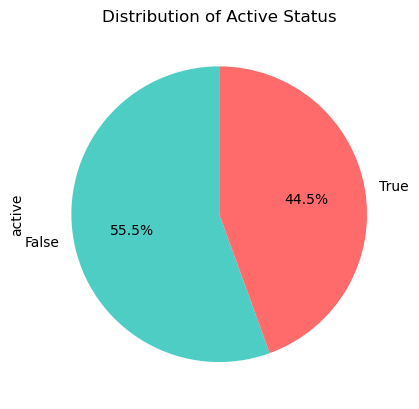

In [136]:
mydata['active'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#4ECDC4', '#FF6B6B'])
plt.title('Distribution of Active Status')

In [137]:
mydata.columns

Index(['campaign_id', 'campaign_name', 'start_date', 'end_date', 'channel',
       'impressions', 'clicks', 'spend', 'conversions', 'active',
       'campaign_tag', 'Season'],
      dtype='object')

$$ \textbf{Machine Learning} $$

In [143]:
mydata['active'] = pd.get_dummies(mydata['active'] , drop_first = True)
print(mydata['active'].head())

0    1
1    0
2    0
3    0
4    1
Name: active, dtype: uint8


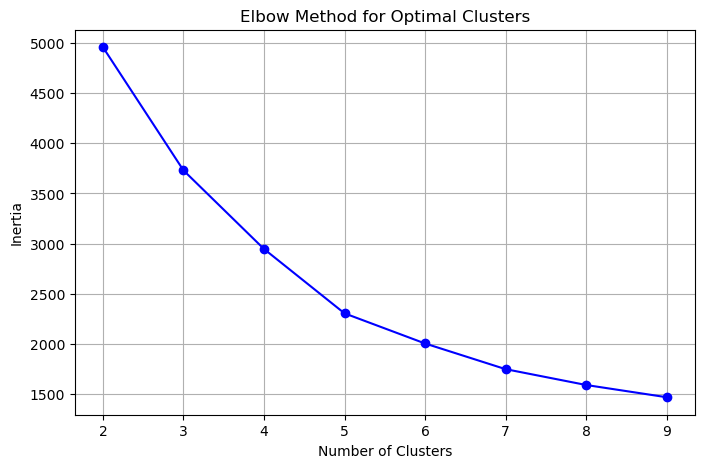

In [145]:

segment_col = ['impressions', 'clicks', 'spend', 'conversions', 'active']

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select the columns for clustering
X = mydata[segment_col].copy()

# Encode active column (True=1, False=0)
#X['active'] = pd.get_dummies(X['active'] , drop_first = True)

# Handle missing values
X = X.dropna()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine optimal clusters using elbow method
inertias = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Clusters')
plt.grid()
plt.show()



In [151]:
# Apply KMeans with optimal clusters (e.g., k=3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
X['Cluster'] = kmeans.fit_predict(X_scaled)

# Assign clusters back to original dataframe
mydata.loc[X.index, 'Cluster'] = X['Cluster']

print(f'Clusters assigned: {mydata["Cluster"].unique()}')
print(f'\nCluster distribution:\n{mydata["Cluster"].value_counts().sort_index()}')

Clusters assigned: [ 2.  1. nan  0.]

Cluster distribution:
0.0    546
1.0    704
2.0    570
Name: Cluster, dtype: int64


In [152]:
mydata.head()

,campaign_id,campaign_name,start_date,end_date,channel,impressions,clicks,spend,conversions,active,campaign_tag,Season,Cluster
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24,2023-12-13,TikTok,16795,197,102.82,20.0,1,TI,Summer,2.0
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06,2023-05-12,Facebook,1860,30,24.33,1.0,0,FA,Launch,1.0
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13,2023-12-20,Email,77820,843,1323.39,51.0,0,EM,Winter,1.0
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,0,TI,BlackFriday,1.0
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22,2023-04-23,Facebook,7265,169,252.44,30.0,1,FA,Winter,2.0


<AxesSubplot:xlabel='clicks', ylabel='impressions'>

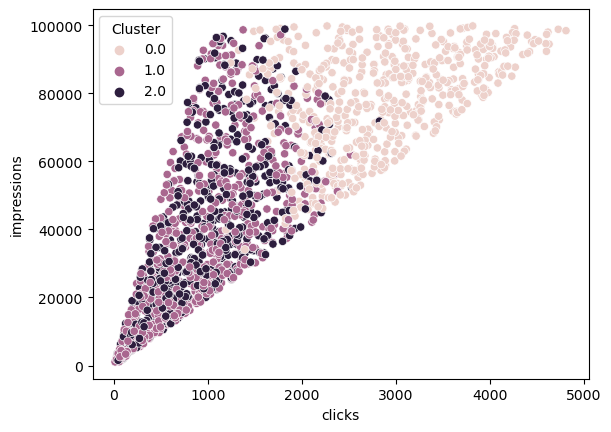

In [154]:
sns.scatterplot(data = mydata,  
            x = 'clicks' , 
            y = 'impressions' , 
            hue = 'Cluster')

$$ \huge\textbf{House Price Prediction Model}$$

In [1]:
# Importing Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
%matplotlib inline

In [2]:
mydata = pd.read_csv('House Price India.csv')
mydata.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


In [3]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14619 non-null  int64  
 1   Date                                   14619 non-null  int64  
 2   number of bedrooms                     14619 non-null  int64  
 3   number of bathrooms                    14619 non-null  float64
 4   living area                            14619 non-null  int64  
 5   lot area                               14619 non-null  int64  
 6   number of floors                       14619 non-null  float64
 7   waterfront present                     14619 non-null  int64  
 8   number of views                        14619 non-null  int64  
 9   condition of the house                 14619 non-null  int64  
 10  grade of the house                     14619 non-null  int64  
 11  Ar

In [6]:
print(mydata.columns.tolist)

mydata.columns = mydata.columns.str.strip()

<bound method IndexOpsMixin.tolist of Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')>


In [10]:
round(mydata.Price.describe().reset_index()['Price'], 2)

0      14619.00
1     538806.28
2     367229.36
3      78000.00
4     320000.00
5     450000.00
6     645000.00
7    7700000.00
Name: Price, dtype: float64

In [11]:
mydata.Price.describe()

count    1.461900e+04
mean     5.388063e+05
std      3.672294e+05
min      7.800000e+04
25%      3.200000e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: Price, dtype: float64

In [ ]:
# Outlier Calculation
Q1 = mydata['Price'].quantile(0.25)
Q3 = mydata['Price'].quantile(0.75)

IQR = Q3 - Q1
upper_limit = Q3 + (3 * IQR)

outliers = mydata['Price'] > upper_limit
print(mydata.loc[outliers, ['id', 'Price']])

               id    Price
75     6762810164  2280000
159    6762810285  1870000
160    6762810310  1800000
242    6762810052  3200000
335    6762810338  1750000
...           ...      ...
14335  6762810359  1720000
14467  6762810118  2500000
14531  6762810050  3300000
14532  6762810244  1950000
14533  6762810377  1700000

[268 rows x 2 columns]


In [19]:
# Nan Check

mydata.isna().sum().sum()

0

In [21]:
# Check Duplicates

mydata.duplicated().sum()

0

In [28]:
mydata.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')>

<AxesSubplot:xlabel='condition of the house'>

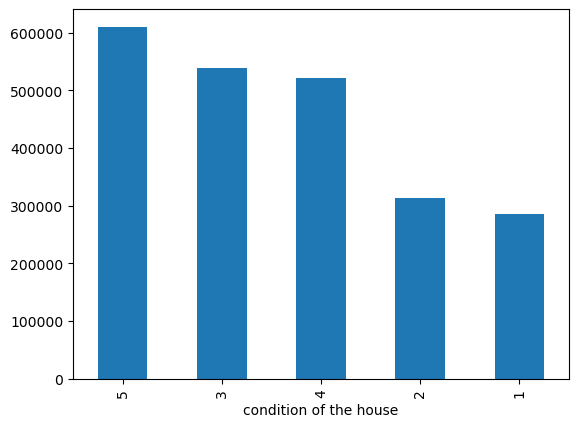

In [30]:
mydata.groupby('condition of the house')['Price'].mean().sort_values(ascending=False).plot(kind = 'bar')


In [41]:
X = mydata[[ 'number of bedrooms', 'number of bathrooms','living area',
            'condition of the house','Number of schools nearby' ]]
y =mydata[['Price']]

In [42]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=.2)


In [43]:
from sklearn.model_selection import GridSearchCV

In [49]:
from sklearn.tree import DecisionTreeRegressor

param_grid = {
    'criterion':['mse' , 'friedman_mse', 'mae'],
    'splitter' :['best' , 'random'],
    'max_depth' :[None , 10,  20,30, 40,50],
    'min_samples_split' :[2,5,10],
    'min_samples_leaf':[1,2,4]
}

In [50]:
tree_model = DecisionTreeRegressor()

In [51]:
grid_tree = GridSearchCV(estimator=tree_model , param_grid= param_grid)

In [52]:
grid_tree.fit(X_train , y_train)

c:\Users\user\anaconda3\lib\site-packages\sklearn\tree\_classes.py:359: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  warnings.warn(
c:\Users\user\anaconda3\lib\site-packages\sklearn\tree\_classes.py:359: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  warnings.warn(
c:\Users\user\anaconda3\lib\site-packages\sklearn\tree\_classes.py:359: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  warnings.warn(
c:\Users\user\anaconda3\lib\site-packages\sklearn\tree\_classes.py:359: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  warnings.warn(
c:\Users\user\anaconda3\lib\site-packages\sklearn\tree\_classes.py:359: 

GridSearchCV(estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['mse', 'friedman_mse', 'mae'],
                         'max_depth': [None, 10, 20, 30, 40, 50],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [53]:
grid_tree.best_params_

{'criterion': 'mse',
 'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 10,
 'splitter': 'random'}

In [54]:
tree_pred = grid_tree.predict(X_test)

In [55]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test , tree_pred)

74698295620.95604

In [57]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [58]:
lr.fit(X_train , y_train)

LinearRegression()

In [59]:
pred_lr = lr.predict(X_test)

In [61]:
mean_squared_error(y_test,pred_lr)

60285174167.49726

In [62]:
from sklearn.ensemble import RandomForestRegressor
rfrmodel = RandomForestRegressor()

In [63]:
param_gridrfr = {
    'max_depth':[5,10,15] , 
    'n_estimators':[2,3,4,5,6,7,8,9,10],
    
}

In [64]:
gridrfr = GridSearchCV(rfrmodel , param_gridrfr)

In [65]:
gridrfr.fit(X_train , y_train.values.ravel())

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_depth': [5, 10, 15],
                         'n_estimators': [2, 3, 4, 5, 6, 7, 8, 9, 10]})

In [66]:
gridrfr.best_params_

{'max_depth': 5, 'n_estimators': 10}

In [67]:
rfrpred = gridrfr.predict(X_test)

In [69]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test , rfrpred)

161846.97240331644

In [70]:
gridrfr

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_depth': [5, 10, 15],
                         'n_estimators': [2, 3, 4, 5, 6, 7, 8, 9, 10]})

In [71]:
import joblib
joblib.dump(gridrfr , 'randomfmodel.pkl')

['randomfmodel.pkl']

In [73]:
X.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['number of bedrooms', 'number of bathrooms', 'living area',
       'condition of the house', 'Number of schools nearby'],
      dtype='object')>

In [75]:
X.describe()

,number of bedrooms,number of bathrooms,living area,condition of the house,Number of schools nearby
count,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000
mean,3.379233,2.129557,2098.156851,3.430399,2.012244
std,0.938655,0.769955,928.218740,0.664047,0.817312
min,1.000000,0.500000,370.000000,1.000000,1.000000
25%,3.000000,1.750000,1440.000000,3.000000,1.000000
50%,3.000000,2.250000,1930.000000,3.000000,2.000000
75%,4.000000,2.500000,2570.000000,4.000000,3.000000
max,33.000000,8.000000,13540.000000,5.000000,3.000000


In [76]:
mydata['living area'].describe()

count    14619.000000
mean      2098.156851
std        928.218740
min        370.000000
25%       1440.000000
50%       1930.000000
75%       2570.000000
max      13540.000000
Name: living area, dtype: float64

$$ \huge\textit{Car Price Prediction Model}$$

In [ ]:
# Importing Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
#import plotly.express as px
#import plotly.graph_objects as go
%matplotlib inline

: 

In [2]:
car_data = pd.read_csv("car_purchasing.csv", encoding = 'latin-1')
car_data.head()

,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


In [3]:
#car_data.age   = round(car_data.age , 0)

In [4]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer name        500 non-null    object 
 1   customer e-mail      500 non-null    object 
 2   country              500 non-null    object 
 3   gender               500 non-null    int64  
 4   age                  500 non-null    float64
 5   annual Salary        500 non-null    float64
 6   credit card debt     500 non-null    float64
 7   net worth            500 non-null    float64
 8   car purchase amount  500 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 35.3+ KB


In [5]:
car_data.columns

Index(['customer name', 'customer e-mail', 'country', 'gender', 'age',
       'annual Salary', 'credit card debt', 'net worth',
       'car purchase amount'],
      dtype='object')

In [6]:
car_data.select_dtypes('number').corr(method = 'pearson')['car purchase amount'].sort_values(ascending = False)

car purchase amount    1.000000
age                    0.632865
annual Salary          0.617862
net worth              0.488580
credit card debt       0.028882
gender                -0.066408
Name: car purchase amount, dtype: float64

In [7]:
import seaborn as sns

<AxesSubplot:>

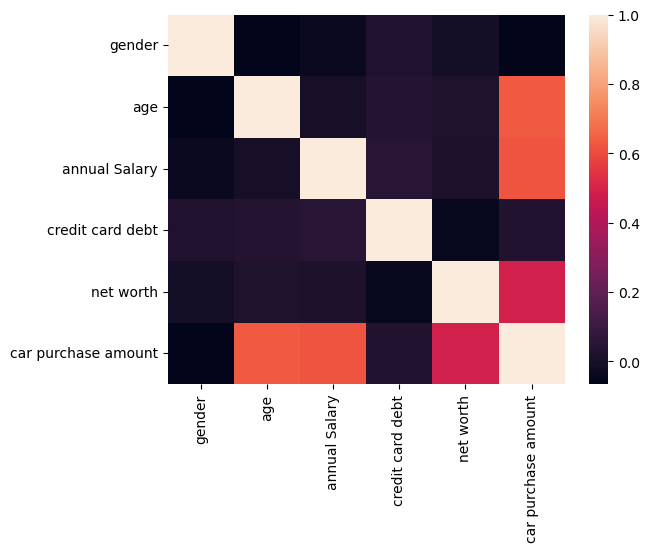

In [8]:
rel = car_data.select_dtypes('number').corr(method = 'pearson')
sns.heatmap(rel)

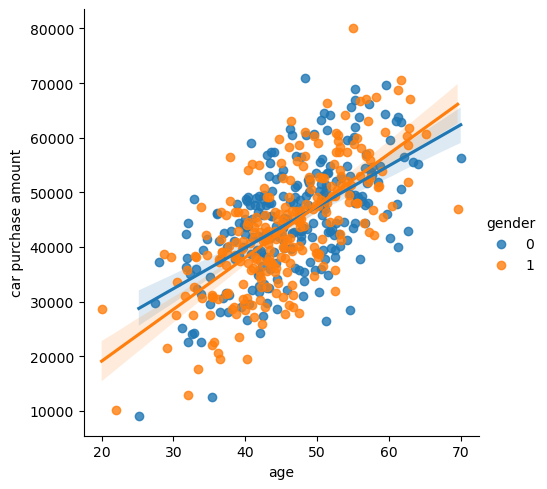

In [9]:
sns.lmplot(data =car_data , x ='age' , y = 'car purchase amount' , hue = 'gender')

In [10]:
car_data['gender2'] = car_data.gender.apply(lambda x: 'Female' if x == 1 else 'Male')

In [11]:
car_data.head()

,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount,gender2
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877,Male
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566,Male
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921,Female
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313,Female
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248,Female


In [12]:
car_data[car_data['country']=='Zimbabwe']

,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount,gender2
159,Sebastian Marks,et.eros@feugiatmetussit.net,Zimbabwe,0,55.989615,39488.45582,10992.33383,363561.1972,37714.31659,Male
496,Vanna,Cum.sociis.natoque@Sedmolestie.edu,Zimbabwe,1,37.642000,56039.49793,12301.45679,360419.0988,31491.41457,Female


In [13]:
car_data.gender2.value_counts()

Female    253
Male      247
Name: gender2, dtype: int64

In [14]:
car_data.groupby('gender2')['annual Salary'].mean()

gender2
Female    61705.593322
Male      62559.128313
Name: annual Salary, dtype: float64

In [15]:
car_data.age.describe()

count    500.000000
mean      46.241674
std        7.978862
min       20.000000
25%       40.949969
50%       46.049901
75%       51.612263
max       70.000000
Name: age, dtype: float64

In [16]:
def age_groups_creation(row):
    
     if row['age']<30:
        return "20-30"
     elif row['age']<40:
        return "30-40"
     elif row['age']<50:
        return "40-50"
     elif row['age']<60:
        return "50-60"
     else:
        return "60-70"

In [17]:
car_data['age_group'] = car_data.apply(age_groups_creation, axis=1)

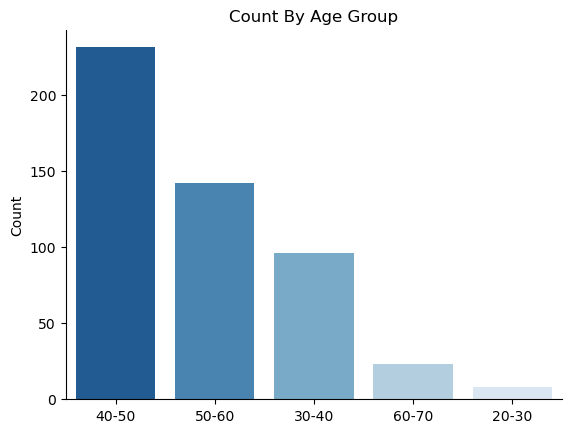

In [26]:
grp =car_data['age_group'].value_counts()

sns.barplot(x = grp.index , y = grp.values , palette='Blues_r')
plt.title('Count By Age Group')
plt.ylabel('Count')
sns.despine()


In [31]:
car_data.columns

Index(['customer name', 'customer e-mail', 'country', 'gender', 'age',
       'annual Salary', 'credit card debt', 'net worth', 'car purchase amount',
       'gender2', 'age_group'],
      dtype='object')

In [35]:
grp2 = car_data.groupby( 'age_group')['annual Salary'].mean().sort_values(ascending=False)
px.bar(x = grp2.index , y = grp2.values , title='Annual Salary by Age Groups' )

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '60-70'),
  Text(1, 0, '50-60'),
  Text(2, 0, '40-50'),
  Text(3, 0, '30-40'),
  Text(4, 0, '20-30')])

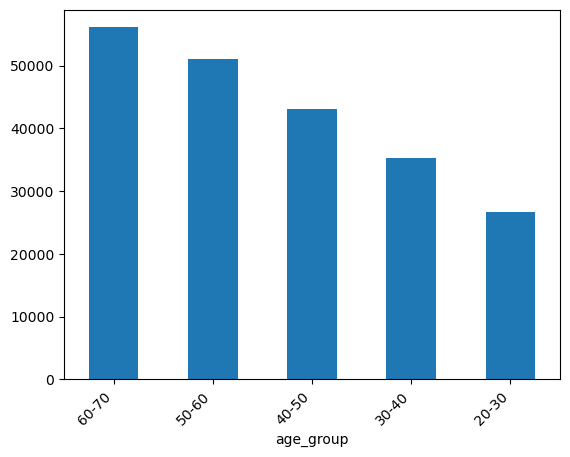

In [42]:
car_data.groupby( 'age_group')['car purchase amount'].mean().round(2).sort_values(ascending=False).plot(kind = 'bar')
plt.xticks(rotation = 45 , ha = 'right')

In [44]:
car_data.groupby(['gender2','age_group' ])['annual Salary'].mean()

gender2  age_group
Female   20-30        61656.174270
         30-40        60474.781313
         40-50        61293.340418
         50-60        63165.221037
         60-70        63876.773028
Male     20-30        61101.667473
         30-40        63300.221926
         40-50        63347.080071
         50-60        62529.281355
         60-70        53885.836882
Name: annual Salary, dtype: float64

In [45]:
car_data.columns

Index(['customer name', 'customer e-mail', 'country', 'gender', 'age',
       'annual Salary', 'credit card debt', 'net worth', 'car purchase amount',
       'gender2', 'age_group'],
      dtype='object')

In [46]:
X = car_data[['age','annual Salary','net worth']]
y = car_data[['car purchase amount']]

$$ \textbf{Feature Engineering} $$

In [49]:
from sklearn.model_selection import train_test_split
X_train  , X_test , y_train , y_test = train_test_split(X , y , test_size= .2)

In [50]:
print(len(X_test))
print(len(y_test))

100
100


In [52]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [53]:
X_train = scaler.fit_transform(X_train)

In [54]:
import joblib
joblib.dump(scaler , 'scaler.pkl')

['scaler.pkl']

In [55]:
X_test = scaler.fit_transform(X_test)

In [56]:
from sklearn.metrics import  mean_absolute_error , mean_squared_error

def modelresult(predictions):
    print('Mean absolute Error on model is {}'.format(mean_absolute_error(y_test, predictions)))
    print('Mean Squared Error on model is {}'.format(mean_squared_error(y_test, predictions)))

$$ \textbf{Linear Model} $$

In [57]:
from sklearn.linear_model import LinearRegression
lr  = LinearRegression()

In [58]:
lr.fit(X_train , y_train)

LinearRegression()

In [60]:
prediction_linear_reg = lr.predict(X_test)

In [61]:
modelresult(prediction_linear_reg)

Mean absolute Error on model is 1018.2712353627503
Mean Squared Error on model is 1509083.4135927602


In [62]:
car_data['car purchase amount'].describe()

count      500.000000
mean     44209.799218
std      10773.178744
min       9000.000000
25%      37629.896040
50%      43997.783390
75%      51254.709517
max      80000.000000
Name: car purchase amount, dtype: float64

In [64]:
lr.coef_.round(2)

array([[6661.51, 6708.81, 5082.21]])

$$ \textbf{Svm}$$

In [65]:
from sklearn.svm import SVR

In [68]:
svrmodel = SVR()


In [69]:
# Parameter Determining

param_gridsvr = {'C':[.01 , .1 , .5] , 
                 'kernel':['linear' , 'rbf' , 'poly'],
                 'degree': [2,3,4]}

In [70]:
from sklearn.model_selection import GridSearchCV
gridsvr = GridSearchCV(svrmodel , param_gridsvr)

In [72]:
gridsvr.fit(X_train , y_train.values.ravel())

GridSearchCV(estimator=SVR(),
             param_grid={'C': [0.01, 0.1, 0.5], 'degree': [2, 3, 4],
                         'kernel': ['linear', 'rbf', 'poly']})

In [74]:
prediction_svr = gridsvr.predict(X_test)

In [75]:
modelresult(prediction_svr)

Mean absolute Error on model is 8504.486238222013
Mean Squared Error on model is 113504854.35718575


In [76]:
gridsvr.best_params_

{'C': 0.5, 'degree': 2, 'kernel': 'linear'}

$$ \textbf{Random Forest} $$

In [85]:
from sklearn.ensemble import RandomForestRegressor
rfr_model = RandomForestRegressor()
param_rfr = {'max_depth':[5,10,15] , 
             'n_estimators' : [10 , 11,12,13,14,15,16]}

In [86]:
gridrf = GridSearchCV(rfr_model , param_rfr)

In [87]:
gridrf.fit(X_train , y_train.values.ravel())

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_depth': [5, 10, 15],
                         'n_estimators': [10, 11, 12, 13, 14, 15, 16]})

In [88]:
prediction_rfr = gridrf.predict(X_test)

In [89]:
modelresult(prediction_rfr)

Mean absolute Error on model is 1760.8326945833333
Mean Squared Error on model is 5532167.814676746


In [90]:
gridrf.best_params_

{'max_depth': 15, 'n_estimators': 12}

In [91]:
joblib.dump(lr , 'linear.pkl')

['linear.pkl']

In [93]:
X.describe()

,age,annual Salary,net worth
count,500.000000,500.000000,500.000000
mean,46.241674,62127.239608,431475.713625
std,7.978862,11703.378228,173536.756340
min,20.000000,20000.000000,20000.000000
25%,40.949969,54391.977195,299824.195900
50%,46.049901,62915.497035,426750.120650
75%,51.612263,70117.862005,557324.478725
max,70.000000,100000.000000,1000000.000000


$$ \huge\textit{AI Intergration} $$

In [ ]:
# Importing Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
%matplotlib inline

: 

In [2]:
fifa_data = pd.read_csv("C:/Users/user/Desktop/Machine Learning Full/archive (1)/FIFA17_official_data.csv")
fifa_data.head()

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Best Position,Best Overall Rating
0,176580,L. Suárez,29,https://cdn.sofifa.com/players/176/580/17_60.png,Uruguay,https://cdn.sofifa.com/flags/uy.png,92,92,FC Barcelona,https://cdn.sofifa.com/teams/241/light_30.png,...,30.0,45.0,38.0,27.0,25.0,31.0,33.0,37.0,ST,88.0
1,178518,R. Nainggolan,28,https://cdn.sofifa.com/players/178/518/17_60.png,Belgium,https://cdn.sofifa.com/flags/be.png,86,86,Roma,https://cdn.sofifa.com/teams/52/light_30.png,...,78.0,85.0,88.0,11.0,11.0,14.0,8.0,11.0,CDM,84.0
2,181872,A. Vidal,29,https://cdn.sofifa.com/players/181/872/17_60.png,Chile,https://cdn.sofifa.com/flags/cl.png,87,87,FC Bayern München,https://cdn.sofifa.com/teams/21/light_30.png,...,76.0,89.0,84.0,4.0,2.0,4.0,2.0,4.0,CDM,85.0
3,197445,D. Alaba,24,https://cdn.sofifa.com/players/197/445/17_60.png,Austria,https://cdn.sofifa.com/flags/at.png,86,89,FC Bayern München,https://cdn.sofifa.com/teams/21/light_30.png,...,81.0,83.0,83.0,5.0,7.0,14.0,15.0,9.0,LB,84.0
4,195864,P. Pogba,23,https://cdn.sofifa.com/players/195/864/17_60.png,France,https://cdn.sofifa.com/flags/fr.png,88,94,Manchester United,https://cdn.sofifa.com/teams/11/light_30.png,...,68.0,73.0,73.0,5.0,6.0,2.0,4.0,3.0,CAM,85.0


In [4]:
fifa_data.head(10)

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Best Position,Best Overall Rating
0,176580,L. Suárez,29,https://cdn.sofifa.com/players/176/580/17_60.png,Uruguay,https://cdn.sofifa.com/flags/uy.png,92,92,FC Barcelona,https://cdn.sofifa.com/teams/241/light_30.png,...,30.0,45.0,38.0,27.0,25.0,31.0,33.0,37.0,ST,88.0
1,178518,R. Nainggolan,28,https://cdn.sofifa.com/players/178/518/17_60.png,Belgium,https://cdn.sofifa.com/flags/be.png,86,86,Roma,https://cdn.sofifa.com/teams/52/light_30.png,...,78.0,85.0,88.0,11.0,11.0,14.0,8.0,11.0,CDM,84.0
2,181872,A. Vidal,29,https://cdn.sofifa.com/players/181/872/17_60.png,Chile,https://cdn.sofifa.com/flags/cl.png,87,87,FC Bayern München,https://cdn.sofifa.com/teams/21/light_30.png,...,76.0,89.0,84.0,4.0,2.0,4.0,2.0,4.0,CDM,85.0
3,197445,D. Alaba,24,https://cdn.sofifa.com/players/197/445/17_60.png,Austria,https://cdn.sofifa.com/flags/at.png,86,89,FC Bayern München,https://cdn.sofifa.com/teams/21/light_30.png,...,81.0,83.0,83.0,5.0,7.0,14.0,15.0,9.0,LB,84.0
4,195864,P. Pogba,23,https://cdn.sofifa.com/players/195/864/17_60.png,France,https://cdn.sofifa.com/flags/fr.png,88,94,Manchester United,https://cdn.sofifa.com/teams/11/light_30.png,...,68.0,73.0,73.0,5.0,6.0,2.0,4.0,3.0,CAM,85.0
5,173731,G. Bale,26,https://cdn.sofifa.com/players/173/731/17_60.png,Wales,https://cdn.sofifa.com/flags/gb-wls.png,90,90,Real Madrid,https://cdn.sofifa.com/teams/243/light_30.png,...,51.0,55.0,52.0,15.0,15.0,11.0,5.0,6.0,ST,88.0
6,203551,A. Florenzi,25,https://cdn.sofifa.com/players/203/551/17_60.png,Italy,https://cdn.sofifa.com/flags/it.png,82,85,Roma,https://cdn.sofifa.com/teams/52/light_30.png,...,73.0,79.0,77.0,9.0,8.0,10.0,11.0,10.0,RB,81.0
7,163631,L. Baines,31,https://cdn.sofifa.com/players/163/631/17_60.png,England,https://cdn.sofifa.com/flags/gb-eng.png,83,83,Everton,https://cdn.sofifa.com/teams/7/light_30.png,...,81.0,82.0,82.0,8.0,15.0,10.0,13.0,12.0,LWB,81.0
8,177003,L. Modrić,30,https://cdn.sofifa.com/players/177/003/17_60.png,Croatia,https://cdn.sofifa.com/flags/hr.png,89,89,Real Madrid,https://cdn.sofifa.com/teams/243/light_30.png,...,66.0,80.0,73.0,13.0,9.0,7.0,14.0,9.0,CM,86.0
9,20801,Cristiano Ronaldo,31,https://cdn.sofifa.com/players/020/801/17_60.png,Portugal,https://cdn.sofifa.com/flags/pt.png,94,94,Real Madrid,https://cdn.sofifa.com/teams/243/light_30.png,...,22.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,ST,91.0


In [8]:
fifa_data_prep = pd.read_csv('fifa_data_cleaned.csv')
fifa_data_prep.iloc[:, 15:]

,Body Type,Real Face,Position,Jersey Number,Joined,Loaned From,Contract Valid Until,Height,Weight,Crossing,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Best Position,Best Overall Rating,Release Clause
0,Normal (170-185),Yes,"<span class=""pos pos26"">LS",9.0,"Jul 11, 2014",NaN,2021,182.88,86.182480,77.0,...,45.0,38.0,27.0,25.0,31.0,33.0,37.0,CF,88.0,€198.9M
1,Stocky (170-185),Yes,"<span class=""pos pos13"">RCM",4.0,"Jan 7, 2014",NaN,2021,175.26,77.110640,73.0,...,86.0,88.0,11.0,11.0,14.0,8.0,11.0,CDM,84.0,€72.3M
2,Lean (170-185),Yes,"<span class=""pos pos3"">RB",24.0,"Jul 1, 2010",NaN,2023,172.72,67.131616,77.0,...,79.0,78.0,9.0,8.0,10.0,11.0,10.0,CF,81.0,€37.3M
3,Lean (170-185),Yes,"<span class=""pos pos7"">LB",27.0,"Feb 10, 2010",NaN,2021,180.34,76.203456,81.0,...,82.0,80.0,5.0,7.0,14.0,15.0,9.0,LB,82.0,€66.4M
4,Lean (185+),Yes,"<span class=""pos pos15"">LCM",6.0,"Aug 9, 2016",NaN,2021,190.50,83.914520,80.0,...,70.0,68.0,5.0,6.0,2.0,4.0,3.0,CM,85.0,€146.3M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17922,Normal (185+),No,"<span class=""pos pos29"">RES",78.0,"Jul 1, 2016",NaN,2020,190.50,78.925008,11.0,...,11.0,13.0,58.0,46.0,57.0,52.0,47.0,GK,50.0,€146K
17923,Lean (185+),No,"<span class=""pos pos29"">RES",41.0,"Jan 26, 2017",NaN,2019,187.96,73.935496,14.0,...,11.0,10.0,46.0,47.0,49.0,42.0,48.0,GK,45.0,€119K
17924,Lean (170-185),No,"<span class=""pos pos29"">RES",22.0,"Jul 1, 2017",NaN,2020,182.88,79.832192,13.0,...,12.0,10.0,45.0,55.0,48.0,45.0,56.0,GK,48.0,€111K
17925,Normal (185+),No,"<span class=""pos pos28"">SUB",1.0,"Jul 1, 2016",NaN,2020,190.50,86.182480,10.0,...,11.0,8.0,55.0,51.0,44.0,55.0,59.0,GK,53.0,€102K


$$ \huge\textit{Laptop Price Prediction} $$

In [1]:
# Importing Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
%matplotlib inline

In [4]:
laptop_data = pd.read_csv('Laptop_price.csv')
laptop_data.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718


In [5]:
laptop_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB


<AxesSubplot:>

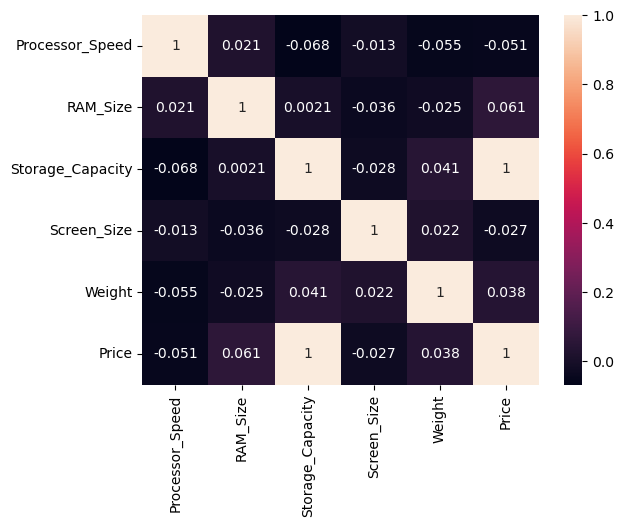

In [11]:
sns.heatmap(laptop_data.select_dtypes('number').corr(method = 'pearson'), annot=True)

In [12]:
laptop_data.describe()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.750611,15.500000,584.576000,14.056790,3.466919,19604.187963
std,0.731796,10.988665,313.438517,1.705882,0.866541,9406.064880
min,1.511580,4.000000,256.000000,11.012111,2.000560,8570.012950
25%,2.089246,8.000000,256.000000,12.635523,2.717211,10114.012948
50%,2.760885,16.000000,512.000000,14.099643,3.464630,17287.241878
75%,3.362610,32.000000,1000.000000,15.528590,4.212583,31566.214754
max,3.998534,32.000000,1000.000000,16.985737,4.990728,33503.935037


In [15]:
laptop_data.isna().sum().sum()

0

In [16]:
laptop_data.duplicated().sum()

0

In [18]:
33503.935037/10

3350.3935037

In [20]:
laptop_data['Zim_Price'] = laptop_data['Price']/10

In [21]:
laptop_data.describe()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price,Zim_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.750611,15.500000,584.576000,14.056790,3.466919,19604.187963,1960.418796
std,0.731796,10.988665,313.438517,1.705882,0.866541,9406.064880,940.606488
min,1.511580,4.000000,256.000000,11.012111,2.000560,8570.012950,857.001295
25%,2.089246,8.000000,256.000000,12.635523,2.717211,10114.012948,1011.401295
50%,2.760885,16.000000,512.000000,14.099643,3.464630,17287.241878,1728.724188
75%,3.362610,32.000000,1000.000000,15.528590,4.212583,31566.214754,3156.621475
max,3.998534,32.000000,1000.000000,16.985737,4.990728,33503.935037,3350.393504


Text(0.5, 1.0, 'Average Price by Brand')

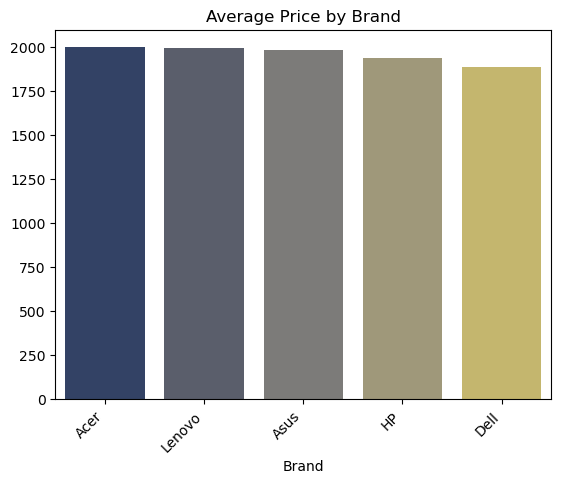

In [25]:
brand= laptop_data.groupby('Brand')['Zim_Price'].mean().sort_values(ascending=False)
sns.barplot(x = brand.index , y = brand.values , palette='cividis')
plt.xticks(rotation = 45 , ha = 'right')
plt.title('Average Price by Brand')

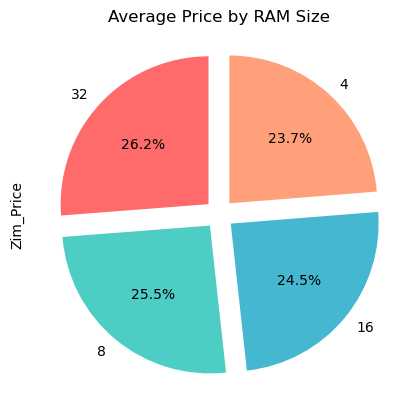

In [30]:
laptop_data.groupby('RAM_Size')['Zim_Price'].mean().sort_values(ascending=False).plot(kind = 'pie' ,
                                                                                      autopct='%1.1f%%' , startangle=90 ,
                                                                                      explode=[.1,.1,.1,.1] ,
                                                                                      colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E2'])
plt.title('Average Price by RAM Size')
plt.show()

In [31]:
laptop_data.columns

Index(['Brand', 'Processor_Speed', 'RAM_Size', 'Storage_Capacity',
       'Screen_Size', 'Weight', 'Price', 'Zim_Price'],
      dtype='object')

In [32]:
y =laptop_data['Zim_Price']
X = laptop_data[['Processor_Speed', 'RAM_Size', 'Storage_Capacity','Screen_Size', 'Weight']]

In [33]:
X

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight
0,3.830296,16,512,11.185147,2.641094
1,2.912833,4,1000,11.311372,3.260012
2,3.241627,4,256,11.853023,2.029061
3,3.806248,16,512,12.280360,4.573865
4,3.268097,32,1000,14.990877,4.193472
...,...,...,...,...,...
995,3.343584,4,1000,12.587095,3.162399
996,2.780555,8,256,12.679356,3.750265
997,3.200569,4,512,12.666315,3.392612
998,1.604182,8,256,11.215581,3.857613


In [34]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = .2)

In [35]:
from sklearn.ensemble import RandomForestRegressor

In [36]:
rfrmodel = RandomForestRegressor()

In [37]:
from sklearn.model_selection import GridSearchCV

In [38]:
param_gridrfr = {
    'max_depth':[2,5,10,15,20,25] ,
    'max_features':['auto', 'sqrt', 'log2'],
    'n_estimators':[2,4,6,8,10,12]}
gridrfr = GridSearchCV(rfrmodel , param_gridrfr)

In [39]:
gridrfr.fit(X_train , y_train)

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_depth': [2, 5, 10, 15, 20, 25],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [2, 4, 6, 8, 10, 12]})

In [40]:
gridrfr.best_params_

{'max_depth': 5, 'max_features': 'auto', 'n_estimators': 12}

In [42]:
predictions = gridrfr.predict(X_test)

In [43]:
from sklearn.metrics import mean_absolute_error , mean_squared_error
print('Mean Absolute Error on model is {}'.format(mean_absolute_error(y_test, predictions)))
print('Mean Squared Error on model is {}'.format(mean_squared_error(y_test, predictions)))

Mean Absolute Error on model is 15.272338695293984
Mean Squared Error on model is 376.34211934526934


In [44]:
laptop_data['Zim_Price'].describe()

count    1000.000000
mean     1960.418796
std       940.606488
min       857.001295
25%      1011.401295
50%      1728.724188
75%      3156.621475
max      3350.393504
Name: Zim_Price, dtype: float64

In [45]:
X.columns.tolist()

['Processor_Speed', 'RAM_Size', 'Storage_Capacity', 'Screen_Size', 'Weight']

In [46]:
import joblib
joblib.dump(gridrfr , 'Zim_Price_model.pkl')

['Zim_Price_model.pkl']

In [47]:
64+128

192